In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Let's first try to modelise a Discrete Hawkes process 

def DHP(kernel,gamma,theta,law,n,alpha0):
    if kernel=="Erlang":
        alpha=np.array([gamma*np.exp(-k*theta)*k for k in range(0,n)])
    if kernel=="Exponential":
        alpha=np.array([gamma*np.exp(-k*theta) for k in range(0,n)])
    
    alpha[0]=alpha0
    X_values=np.zeros(n)
    Sn=np.zeros(n)


    if law=="Bernouilli":
        X_values[0]=np.random.binomial(1,alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.binomial(1,alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]
    if law=="Poisson":
        X_values[0]=np.random.poisson(alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.poisson(alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]


    mu=alpha0/(1+alpha[0]-np.sum(alpha)) #on veut pas d'alpha0 or np.sum(alpha) l'inclut

    if law=="Bernouilli":
        sigma_asy=mu*(1-mu)/((1+alpha[0]-np.sum(alpha))**2) #same
    if law=="Poisson":
        sigma_asy=mu/((1+alpha[0]-np.sum(alpha))**2) #same


    plt.plot(Sn)
    plt.title(f"Discrete Hawkes process with law : {law}, kernel : {kernel}, gamma : {gamma} and theta : {theta}")
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

    plt.plot(Sn/n)
    plt.title("Sn/n")
    plt.axhline(mu, color="red")
    plt.axhspan(mu - 1.96*sigma_asy/(np.sqrt(n)), mu + 1.96*sigma_asy/np.sqrt(n),
    color="orange",
    alpha=0.2
    )
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

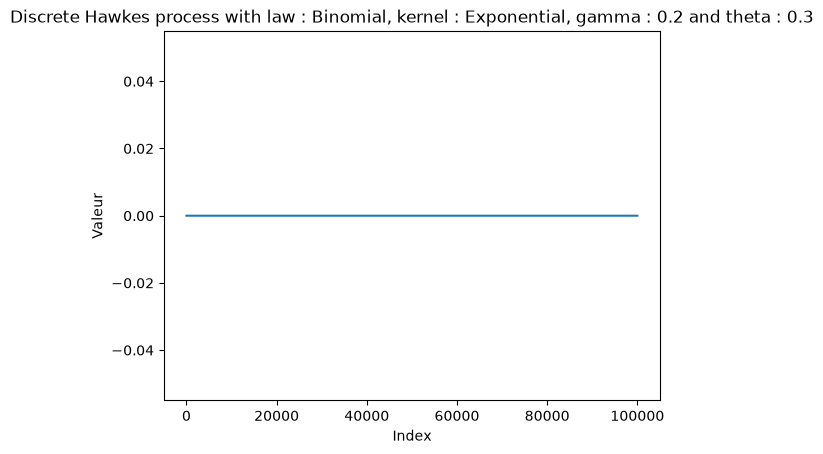

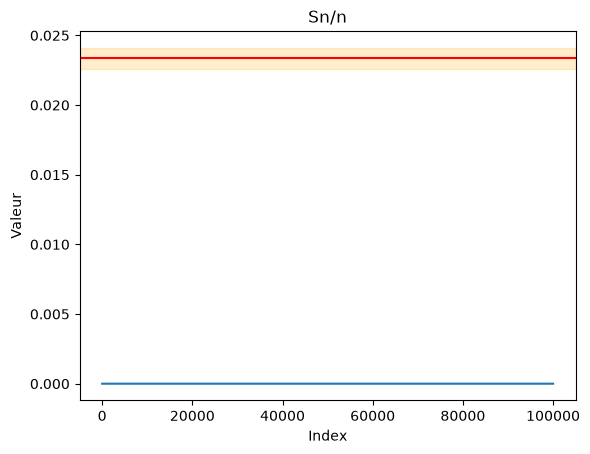

In [ ]:
DHP("Exponential", 0.2, 0.3, "Poisson", 100000, 0.01)